# Relapse/MRD multiclass analysis

This notebook analyzes the completed per-patient 4-class relapse/MRD benchmark at:

- `MRD_cancer`
- `MRD_normal`
- `Relapse_cancer`
- `Relapse_normal`

Current goals:

1. inspect per-patient multiclass regularization paths across DR methods
2. summarize patient heterogeneity in macro and class-specific performance
3. relate predictive performance to latent-space tech mixing diagnostics
4. project best-model class coefficients back to genes for biological interpretation
5. optionally run Hallmark GSEA on class-specific predictive signatures

Important limitation for this run:

- the benchmark saved **full CV metric grids** for all hyperparameters
- but it saved **refit coefficients only for the chosen best model**, not for every alpha along the path

So this notebook can visualize multiclass performance paths, but it cannot reconstruct coefficient sparsity paths without a rerun that exports refit coefficients for all hyperparameter settings.

## Research questions to keep in mind

- Which patients show strong `MRD_cancer` vs `Relapse_cancer` separation, and which remain ambiguous?
- Which DR method gives the most stable multiclass performance across patients?
- Does stronger tech separation in latent space track worse biological discrimination?
- Are relapse-associated cancer signatures convergent across patients, or highly patient-specific?
- Do normal-state signatures also shift from MRD to relapse, or is progression concentrated in cancer cells?

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Optional
import math
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("notebook")
sns.set_style("whitegrid")

RUN_DIR = Path(
    "/home/minhang/mds_project/sc_classification/experiments/20260313_192016_relapse_mrd_dr_classification"
)
MULTICLASS_DIR = RUN_DIR / "multiclass_cv"
PATIENT_DR_DIR = RUN_DIR / "patient_dr"
OUTPUT_DIR = Path(
    "/home/minhang/mds_project/sc_classification/scripts/Relapse_MRD_DR_Classification/notebooks/outputs/relapse_mrd_multiclass_analysis_20260319"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["MRD_cancer", "MRD_normal", "Relapse_cancer", "Relapse_normal"]
BEST_PRIMARY_METRIC = "oof_macro_f1"

print(f"RUN_DIR:        {RUN_DIR}")
print(f"MULTICLASS_DIR: {MULTICLASS_DIR}")
print(f"PATIENT_DR_DIR: {PATIENT_DR_DIR}")
print(f"OUTPUT_DIR:     {OUTPUT_DIR}")

feasibility_df = pd.read_csv(RUN_DIR / "input_diagnostics" / "patient_feasibility_summary.csv")
multiclass_best = pd.read_csv(MULTICLASS_DIR / "multiclass_best_by_patient.csv")
multiclass_grid = pd.read_csv(MULTICLASS_DIR / "multiclass_grid_metrics.csv")
multiclass_coef = pd.read_csv(MULTICLASS_DIR / "multiclass_refit_coefficients.csv")
run_manifest = pd.read_csv(MULTICLASS_DIR / "run_manifest.csv")

for df in [multiclass_best, multiclass_grid, multiclass_coef]:
    for col in ["alpha", "C", "l1_ratio", "oof_macro_f1", "oof_balanced_accuracy", "macro_f1_mean", "balanced_accuracy_mean", "macro_auc_ovr_mean", "macro_ap_ovr_mean", "coef", "abs_coef"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

print("Feasibility rows:", feasibility_df.shape)
print("Multiclass best rows:", multiclass_best.shape)
print("Multiclass grid rows:", multiclass_grid.shape)
print("Best-model coefficient rows:", multiclass_coef.shape)

RUN_DIR:        /home/minhang/mds_project/sc_classification/experiments/20260313_192016_relapse_mrd_dr_classification
MULTICLASS_DIR: /home/minhang/mds_project/sc_classification/experiments/20260313_192016_relapse_mrd_dr_classification/multiclass_cv
PATIENT_DR_DIR: /home/minhang/mds_project/sc_classification/experiments/20260313_192016_relapse_mrd_dr_classification/patient_dr
OUTPUT_DIR:     /home/minhang/mds_project/sc_classification/scripts/Relapse_MRD_DR_Classification/notebooks/outputs/relapse_mrd_multiclass_analysis_20260319
Feasibility rows: (13, 11)
Multiclass best rows: (24, 116)
Multiclass grid rows: (2400, 76)
Best-model coefficient rows: (3840, 10)


In [2]:
display(feasibility_df.sort_values(["min_four_class_support", "patient"], ascending=[False, True]).reset_index(drop=True))
display(run_manifest.sort_values(["patient", "method"]).reset_index(drop=True))
display(
    multiclass_best[
        [
            "patient",
            "method",
            "penalty",
            "alpha",
            "l1_ratio",
            "oof_macro_f1",
            "oof_balanced_accuracy",
            "oof_macro_auc_ovr",
            "oof_macro_ap_ovr",
            "nonzero_coef_count",
            "label_by_tech_neighbor_fraction",
        ]
    ]
    .sort_values(["oof_macro_f1", "patient"], ascending=[False, True])
    .reset_index(drop=True)
)

hier_path = RUN_DIR / "hierarchical_cv" / "hierarchical_best_by_patient_task.csv"
if hier_path.exists():
    hierarchical_best = pd.read_csv(hier_path)
    display(hierarchical_best.head())
else:
    print("No hierarchical benchmark outputs were found for this run; this notebook focuses on multiclass_cv.")

,patient,n_cells,has_MRD,has_Relapse,n_timepoints,tech_values,n_MRD_cancer,n_MRD_normal,n_Relapse_cancer,n_Relapse_normal,min_four_class_support
0,P09,18781,True,True,2,"CITE,Multi",375,16751,1045,610,375
1,P02,13581,True,True,2,"CITE,Multi",230,2100,6460,4791,230
2,P03,9793,True,True,2,"CITE,Multi",758,3280,5586,169,169
3,P01,21703,True,True,2,"CITE,Multi",65,18899,1484,1255,65
4,P07,6602,True,True,2,"CITE,Multi",22,2163,4320,97,22
5,P04,8602,True,True,2,"CITE,Multi",102,1026,7459,15,15
6,P05,8694,True,True,2,"CITE,Multi",8,4351,4166,169,8
7,P13,10113,True,True,2,CITE,4,5770,3787,552,4
8,P06,3259,True,False,1,CITE,44,3215,0,0,0
9,P08,2853,True,True,2,"CITE,Multi",0,1411,568,874,0


,patient,method,status,cv_folds_used,n_MRD_cancer,n_MRD_normal,n_Relapse_cancer,n_Relapse_normal
0,P01,fa,completed,5,65,18899,1484,1255
1,P01,factosig,completed,5,65,18899,1484,1255
2,P01,pca,completed,5,65,18899,1484,1255
3,P02,fa,completed,5,230,2100,6460,4791
4,P02,factosig,completed,5,230,2100,6460,4791
5,P02,pca,completed,5,230,2100,6460,4791
6,P03,fa,completed,5,758,3280,5586,169
7,P03,factosig,completed,5,758,3280,5586,169
8,P03,pca,completed,5,758,3280,5586,169
9,P04,fa,completed,5,102,1026,7459,15


,patient,method,penalty,alpha,l1_ratio,oof_macro_f1,oof_balanced_accuracy,oof_macro_auc_ovr,oof_macro_ap_ovr,nonzero_coef_count,label_by_tech_neighbor_fraction
0,P03,factosig,elasticnet,0.615848,0.9,0.973899,0.963285,0.999387,0.982831,104,0.980415
1,P03,pca,l2,5.455595,NaN,0.971744,0.965387,0.999395,0.985112,160,0.985125
2,P09,pca,l2,1.832981,NaN,0.968187,0.960533,0.999455,0.990019,160,0.988038
3,P03,fa,elasticnet,0.206914,0.9,0.967607,0.963964,0.999525,0.983751,127,0.977161
4,P09,factosig,elasticnet,0.615848,0.5,0.963849,0.954681,0.999477,0.988405,133,0.996113
5,P09,fa,l1,0.615848,NaN,0.959225,0.949590,0.999465,0.988994,116,0.995534
6,P04,pca,l2,1.832981,NaN,0.870909,0.855833,0.984585,0.854814,160,0.997497
7,P04,fa,l1,0.069519,NaN,0.858427,0.839620,0.985477,0.849162,109,0.991103
8,P04,factosig,elasticnet,0.069519,0.9,0.854096,0.820292,0.981373,0.858363,115,0.992521
9,P01,fa,elasticnet,0.002637,0.1,0.851505,0.805172,0.985948,0.884592,160,0.984150


No hierarchical benchmark outputs were found for this run; this notebook focuses on multiclass_cv.


In [3]:
def pretty_ratio(v: float) -> str:
    return "NA" if pd.isna(v) else f"{float(v):g}"


def plot_macro_metric_panel(ax, df: pd.DataFrame, title: str):
    d = df.sort_values("alpha")
    x = d["alpha"].values

    for metric, label, marker in [
        ("macro_f1_mean", "macro-F1", "o"),
        ("balanced_accuracy_mean", "balanced accuracy", "s"),
        ("macro_auc_ovr_mean", "macro AUC OvR", "^"),
        ("macro_ap_ovr_mean", "macro AP OvR", "D"),
    ]:
        std_col = metric.replace("_mean", "_std")
        yerr = d[std_col] if std_col in d.columns else None
        if metric in d.columns:
            if yerr is not None:
                ax.errorbar(x, d[metric], yerr=yerr, fmt=f"{marker}-", markersize=4, capsize=3, lw=1.5, label=label)
            else:
                ax.plot(x, d[metric], f"{marker}-", markersize=4, lw=1.5, label=label)

    ax.set_xscale("log")
    ax.set_xlabel("alpha (log scale)")
    ax.set_ylabel("metric")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", frameon=True)


def plot_class_recall_panel(ax, df: pd.DataFrame, title: str):
    d = df.sort_values("alpha")
    x = d["alpha"].values
    palette = {
        "MRD_cancer": "#b2182b",
        "MRD_normal": "#2166ac",
        "Relapse_cancer": "#ef8a62",
        "Relapse_normal": "#67a9cf",
    }
    for cls in CLASS_NAMES:
        col = f"recall_{cls}_mean"
        std_col = f"recall_{cls}_std"
        if col not in d.columns:
            continue
        yerr = d[std_col] if std_col in d.columns else None
        if yerr is not None:
            ax.errorbar(x, d[col], yerr=yerr, fmt="o-", markersize=3.5, capsize=2.5, lw=1.4, color=palette[cls], label=cls)
        else:
            ax.plot(x, d[col], "o-", markersize=3.5, lw=1.4, color=palette[cls], label=cls)

    ax.set_xscale("log")
    ax.set_xlabel("alpha (log scale)")
    ax.set_ylabel("class recall")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", frameon=True, fontsize=8)


def plot_multiclass_heatmaps(df: pd.DataFrame, title_prefix: str):
    if "l1_ratio" not in df.columns or df["l1_ratio"].isna().all():
        return None

    metrics = [
        ("macro_f1_mean", "macro-F1", "viridis"),
        ("balanced_accuracy_mean", "balanced accuracy", "magma"),
        ("macro_auc_ovr_mean", "macro AUC OvR", "crest"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
    for ax, (metric, label, cmap) in zip(axes, metrics):
        piv = df.pivot_table(index="l1_ratio", columns="alpha", values=metric, aggfunc="mean")
        sns.heatmap(piv, cmap=cmap, ax=ax)
        ax.set_title(f"{title_prefix} | {label}")
        ax.set_xlabel("alpha")
        ax.set_ylabel("l1_ratio")
    return fig


plot_dir = OUTPUT_DIR / "per_patient_multiclass_paths"
plot_dir.mkdir(parents=True, exist_ok=True)

saved = []
for (patient, method), gdf in multiclass_grid.groupby(["patient", "method"], observed=False):
    base = f"{patient}__{method}"
    fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), constrained_layout=True)
    plot_macro_metric_panel(axes[0], gdf, title=f"{patient} | {method} | macro metrics")
    plot_class_recall_panel(axes[1], gdf, title=f"{patient} | {method} | class recalls")
    out = plot_dir / f"{base}__path_metrics.png"
    fig.savefig(out, dpi=160)
    plt.close(fig)
    saved.append(out)

    en = gdf[gdf["penalty"] == "elasticnet"].copy()
    hm = plot_multiclass_heatmaps(en, title_prefix=f"{patient} | {method} | elasticnet")
    if hm is not None:
        out_hm = plot_dir / f"{base}__elasticnet_heatmaps.png"
        hm.savefig(out_hm, dpi=160)
        plt.close(hm)
        saved.append(out_hm)

print(f"Saved {len(saved)} multiclass path figures to {plot_dir}")

Saved 48 multiclass path figures to /home/minhang/mds_project/sc_classification/scripts/Relapse_MRD_DR_Classification/notebooks/outputs/relapse_mrd_multiclass_analysis_20260319/per_patient_multiclass_paths


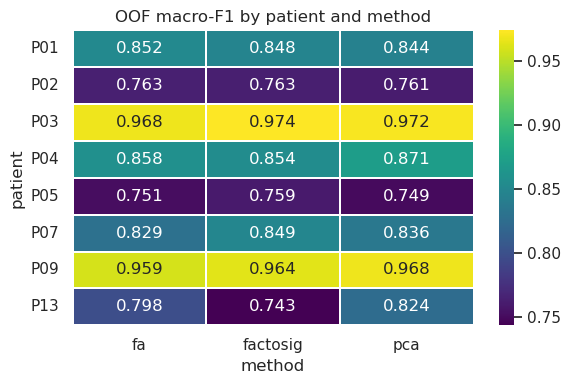

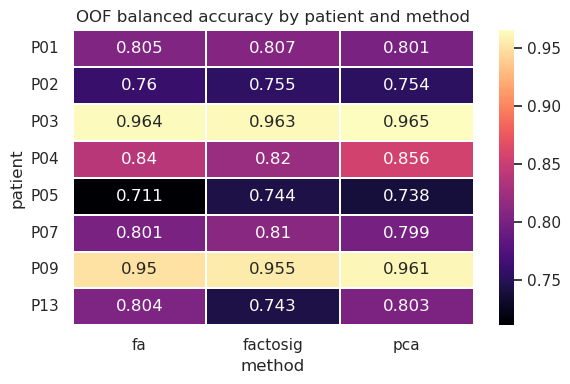

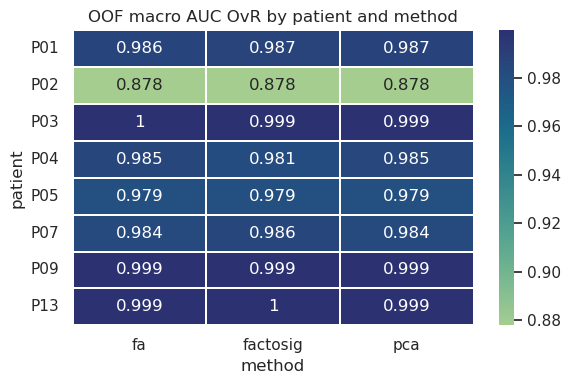

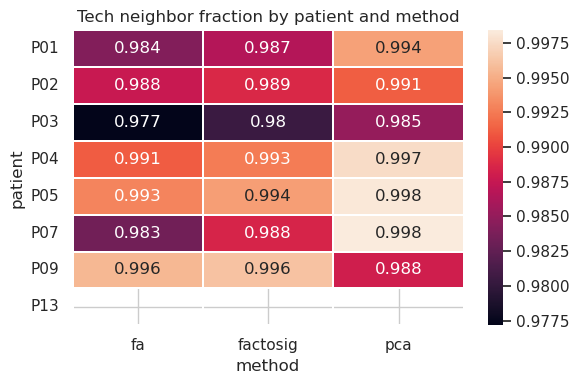

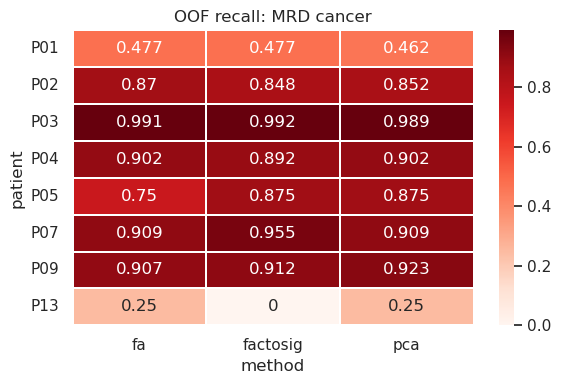

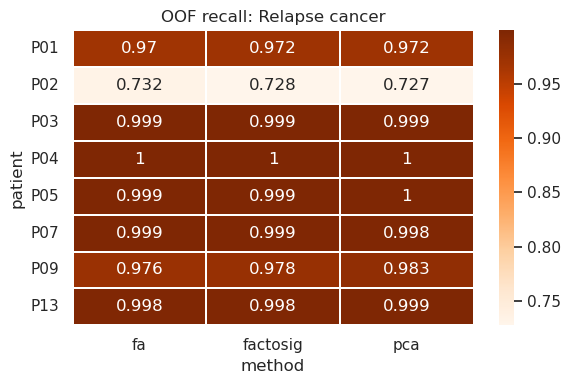

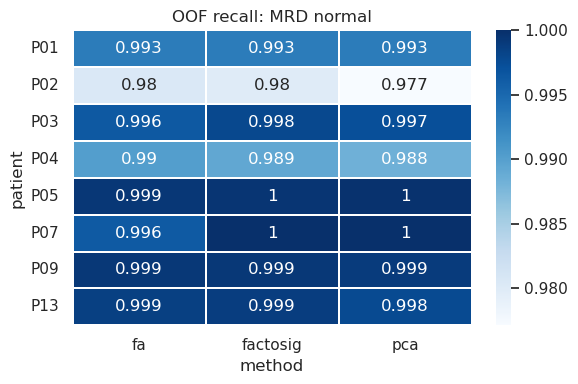

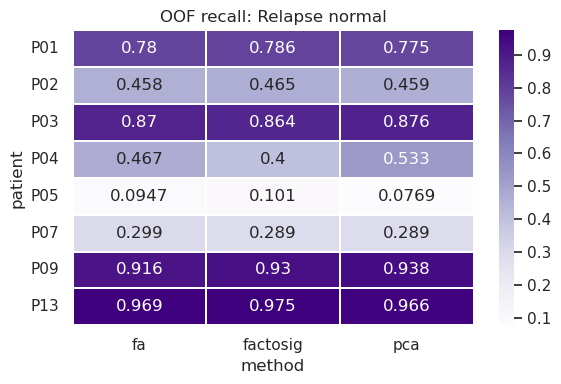

,patient,method,penalty,alpha,l1_ratio,oof_macro_f1,oof_balanced_accuracy,oof_macro_auc_ovr,oof_recall_MRD_cancer,oof_recall_Relapse_cancer,nonzero_coef_count,label_by_tech_neighbor_fraction
0,P01,fa,elasticnet,0.002637,0.1,0.851505,0.805172,0.985948,0.476923,0.970350,160,0.984150
1,P02,fa,elasticnet,0.615848,0.1,0.763212,0.760034,0.878163,0.869565,0.731734,160,0.987699
2,P03,factosig,elasticnet,0.615848,0.9,0.973899,0.963285,0.999387,0.992084,0.999284,104,0.980415
3,P04,pca,l2,1.832981,NaN,0.870909,0.855833,0.984585,0.901961,0.999732,160,0.997497
4,P05,factosig,l1,0.069519,NaN,0.758832,0.743603,0.978664,0.875000,0.999280,88,0.994211
5,P07,factosig,l1,0.007848,NaN,0.848844,0.810454,0.985557,0.954545,0.998611,101,0.988478
6,P09,pca,l2,1.832981,NaN,0.968187,0.960533,0.999455,0.922667,0.982775,160,0.988038
7,P13,pca,elasticnet,0.007848,0.9,0.824141,0.803002,0.998819,0.250000,0.998680,114,NaN


,method,n_patients,mean_macro_f1,sd_macro_f1,mean_balanced_accuracy,sd_balanced_accuracy,mean_macro_auc,mean_tech_neighbor_fraction
2,pca,8,0.853054,0.082949,0.834518,0.086772,0.976285,0.993268
0,fa,8,0.847195,0.081279,0.829247,0.087490,0.976223,0.987422
1,factosig,8,0.844105,0.088973,0.824705,0.088424,0.976158,0.989570


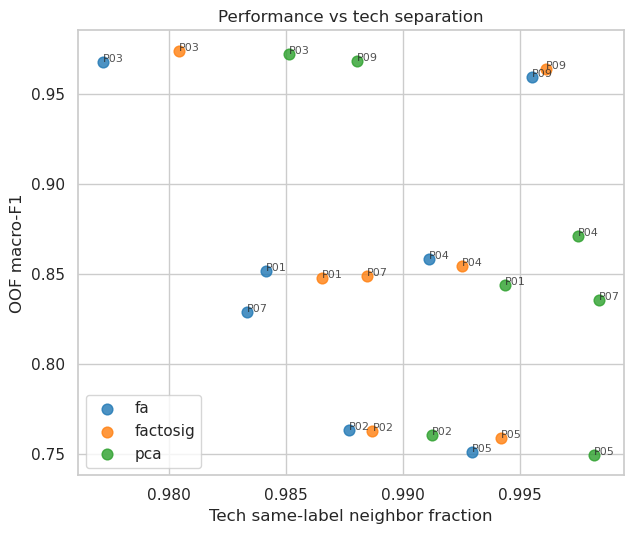

Saved best-per-patient and method summary tables to OUTPUT_DIR


In [4]:
def plot_patient_method_heatmap(df: pd.DataFrame, value_col: str, title: str, cmap: str = "viridis", center: float | None = None):
    mat = df.pivot(index="patient", columns="method", values=value_col)
    mat = mat.reindex(index=sorted(mat.index), columns=sorted(mat.columns))
    fig, ax = plt.subplots(figsize=(max(6, 1.2 * mat.shape[1]), max(4, 0.5 * mat.shape[0])))
    sns.heatmap(mat, cmap=cmap, center=center, linewidths=0.2, linecolor="white", annot=True, fmt=".3g", ax=ax)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.show()


plot_patient_method_heatmap(multiclass_best, "oof_macro_f1", "OOF macro-F1 by patient and method", cmap="viridis")
plot_patient_method_heatmap(multiclass_best, "oof_balanced_accuracy", "OOF balanced accuracy by patient and method", cmap="magma")
plot_patient_method_heatmap(multiclass_best, "oof_macro_auc_ovr", "OOF macro AUC OvR by patient and method", cmap="crest")
plot_patient_method_heatmap(multiclass_best, "label_by_tech_neighbor_fraction", "Tech neighbor fraction by patient and method", cmap="rocket")
plot_patient_method_heatmap(multiclass_best, "oof_recall_MRD_cancer", "OOF recall: MRD cancer", cmap="Reds")
plot_patient_method_heatmap(multiclass_best, "oof_recall_Relapse_cancer", "OOF recall: Relapse cancer", cmap="Oranges")
plot_patient_method_heatmap(multiclass_best, "oof_recall_MRD_normal", "OOF recall: MRD normal", cmap="Blues")
plot_patient_method_heatmap(multiclass_best, "oof_recall_Relapse_normal", "OOF recall: Relapse normal", cmap="Purples")

best_by_patient = (
    multiclass_best.sort_values([BEST_PRIMARY_METRIC, "oof_balanced_accuracy", "oof_macro_auc_ovr"], ascending=[False, False, False])
    .groupby("patient", observed=False)
    .head(1)
    .sort_values("patient")
    .reset_index(drop=True)
)

display(
    best_by_patient[
        [
            "patient",
            "method",
            "penalty",
            "alpha",
            "l1_ratio",
            "oof_macro_f1",
            "oof_balanced_accuracy",
            "oof_macro_auc_ovr",
            "oof_recall_MRD_cancer",
            "oof_recall_Relapse_cancer",
            "nonzero_coef_count",
            "label_by_tech_neighbor_fraction",
        ]
    ]
)

perf_summary = (
    multiclass_best.groupby("method", observed=False)
    .agg(
        n_patients=("patient", "nunique"),
        mean_macro_f1=("oof_macro_f1", "mean"),
        sd_macro_f1=("oof_macro_f1", "std"),
        mean_balanced_accuracy=("oof_balanced_accuracy", "mean"),
        sd_balanced_accuracy=("oof_balanced_accuracy", "std"),
        mean_macro_auc=("oof_macro_auc_ovr", "mean"),
        mean_tech_neighbor_fraction=("label_by_tech_neighbor_fraction", "mean"),
    )
    .reset_index()
    .sort_values("mean_macro_f1", ascending=False)
)
display(perf_summary)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for method, sub in multiclass_best.groupby("method", observed=False):
    ax.scatter(
        sub["label_by_tech_neighbor_fraction"],
        sub["oof_macro_f1"],
        label=method,
        s=60,
        alpha=0.8,
    )
for _, row in multiclass_best.iterrows():
    ax.text(row["label_by_tech_neighbor_fraction"], row["oof_macro_f1"], row["patient"], fontsize=8, alpha=0.8)
ax.set_xlabel("Tech same-label neighbor fraction")
ax.set_ylabel("OOF macro-F1")
ax.set_title("Performance vs tech separation")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

best_by_patient.to_csv(OUTPUT_DIR / "multiclass_best_method_per_patient.csv", index=False)
perf_summary.to_csv(OUTPUT_DIR / "multiclass_method_performance_summary.csv", index=False)
print("Saved best-per-patient and method summary tables to OUTPUT_DIR")

Class-signature matrix shape: (17563, 96)


,patient,method,class_label,penalty,alpha,l1_ratio
4,P01,fa,MRD_cancer,elasticnet,0.002637,0.1
5,P01,fa,MRD_normal,elasticnet,0.002637,0.1
6,P01,fa,Relapse_cancer,elasticnet,0.002637,0.1
7,P01,fa,Relapse_normal,elasticnet,0.002637,0.1
8,P01,factosig,MRD_cancer,elasticnet,0.069519,0.5


,patient,method,comparison,cosine_similarity,top200_positive_jaccard
0,P01,fa,cancer_progression,NaN,0.000000
2,P01,factosig,cancer_progression,NaN,0.000000
4,P01,pca,cancer_progression,NaN,0.084011
6,P02,fa,cancer_progression,NaN,0.000000
8,P02,factosig,cancer_progression,NaN,0.000000
10,P02,pca,cancer_progression,NaN,0.002506
12,P03,fa,cancer_progression,NaN,0.000000
14,P03,factosig,cancer_progression,NaN,0.020408
16,P03,pca,cancer_progression,NaN,0.038961
18,P04,fa,cancer_progression,NaN,0.028278


/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


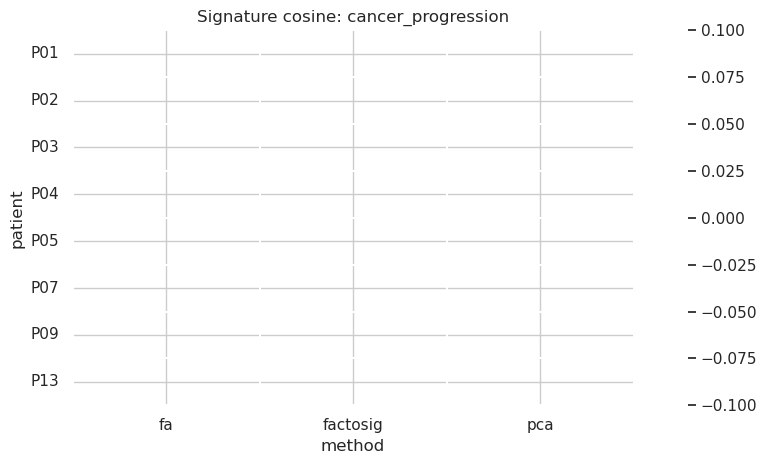

/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


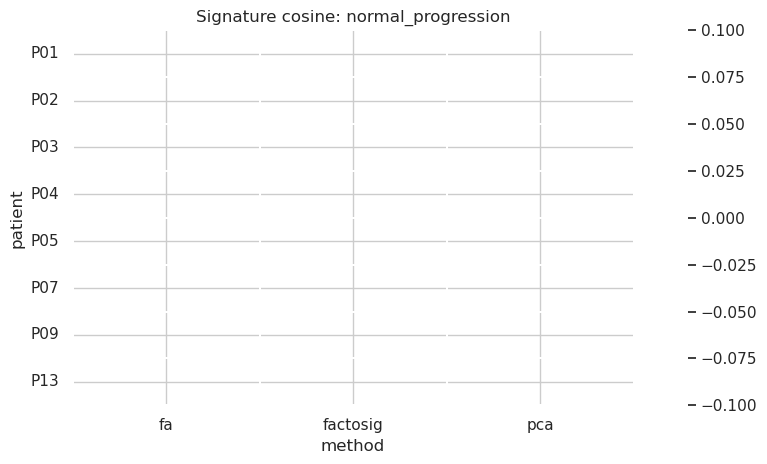

/tmp/ipykernel_699691/1481794053.py:135: RuntimeWarning: Mean of empty slice
  "mean_pairwise_cosine": float(np.nanmean(vals)),
/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_699691/1481794053.py:135: RuntimeWarning: Mean of empty slice
  "mean_pairwise_cosine": float(np.nanmean(vals)),
/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_699691/1481794053.py:135: RuntimeWarning: Mean of empty slice
  "mean_pairwise_cosine": float(np.nanmean(vals)),
/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: Runtim

,method,class_label,n_patients,mean_pairwise_cosine,sd_pairwise_cosine
0,fa,MRD_cancer,8,NaN,NaN
4,factosig,MRD_cancer,8,NaN,NaN
8,pca,MRD_cancer,8,NaN,NaN
1,fa,MRD_normal,8,NaN,NaN
5,factosig,MRD_normal,8,NaN,NaN
9,pca,MRD_normal,8,NaN,NaN
2,fa,Relapse_cancer,8,NaN,NaN
6,factosig,Relapse_cancer,8,NaN,NaN
10,pca,Relapse_cancer,8,NaN,NaN
3,fa,Relapse_normal,8,NaN,NaN


Saved class-signature summaries to /home/minhang/mds_project/sc_classification/scripts/Relapse_MRD_DR_Classification/notebooks/outputs/relapse_mrd_multiclass_analysis_20260319/class_signatures


In [5]:
def load_patient_dr_artifacts(method_dir: Path) -> tuple[pd.DataFrame, np.ndarray, np.ndarray, list[str], list[str]]:
    metadata = pd.read_csv(method_dir / "metadata.csv", index_col=0)
    scores = np.load(method_dir / "scores.npy")
    loadings = np.load(method_dir / "loadings.npy")
    feature_names = pd.read_csv(method_dir / "feature_names.csv")["feature"].astype(str).tolist()
    gene_names = pd.read_csv(method_dir / "gene_names.csv")["gene"].astype(str).tolist()
    return metadata, scores, loadings, feature_names, gene_names


def build_class_signature_matrix(best_df: pd.DataFrame, coef_df: pd.DataFrame, patient_dr_dir: Path) -> pd.DataFrame:
    signatures = {}
    meta_rows = []

    for _, row in best_df.iterrows():
        patient = row["patient"]
        method = row["method"]
        method_dir = patient_dr_dir / str(patient) / str(method)
        _, _, loadings, feature_names, gene_names = load_patient_dr_artifacts(method_dir)
        L = pd.DataFrame(loadings, index=gene_names, columns=[str(x) for x in feature_names])

        c = coef_df[(coef_df["patient"] == patient) & (coef_df["method"] == method)].copy()
        if c.empty:
            continue

        for class_label, sub in c.groupby("class_label", observed=False):
            w = sub.groupby("feature", observed=False)["coef"].mean()
            w.index = w.index.astype(str)
            w = w.reindex(L.columns).fillna(0.0)
            s = L.values @ w.values
            model_uid = f"{patient}|{method}|{class_label}"
            signatures[model_uid] = pd.Series(s, index=L.index)
            meta_rows.append(
                {
                    "patient": patient,
                    "method": method,
                    "class_label": class_label,
                    "penalty": row["penalty"],
                    "alpha": row["alpha"],
                    "l1_ratio": row.get("l1_ratio", np.nan),
                }
            )

    sig_df = pd.DataFrame(signatures)
    meta_df = pd.DataFrame(meta_rows).drop_duplicates().sort_values(["patient", "method", "class_label"])
    return sig_df, meta_df


def cosine_similarity_matrix(X: pd.DataFrame) -> pd.DataFrame:
    A = X.values
    denom = np.linalg.norm(A, axis=0, keepdims=True)
    denom[denom == 0] = 1.0
    A_norm = A / denom
    sim = A_norm.T @ A_norm
    return pd.DataFrame(sim, index=X.columns, columns=X.columns)


def jaccard(a: set, b: set) -> float:
    union_size = len(a | b)
    return len(a & b) / union_size if union_size > 0 else np.nan


sig_df, class_sig_meta = build_class_signature_matrix(multiclass_best, multiclass_coef, PATIENT_DR_DIR)
print("Class-signature matrix shape:", sig_df.shape)
display(class_sig_meta.head())

signature_out = OUTPUT_DIR / "class_signatures"
signature_out.mkdir(parents=True, exist_ok=True)
sig_df.to_csv(signature_out / "multiclass_class_signature_matrix.csv")
class_sig_meta.to_csv(signature_out / "multiclass_class_signature_metadata.csv", index=False)

TOP_N = 200
progression_rows = []
for (patient, method), sub in class_sig_meta.groupby(["patient", "method"], observed=False):
    cancer_a = f"{patient}|{method}|MRD_cancer"
    cancer_b = f"{patient}|{method}|Relapse_cancer"
    normal_a = f"{patient}|{method}|MRD_normal"
    normal_b = f"{patient}|{method}|Relapse_normal"

    if cancer_a in sig_df.columns and cancer_b in sig_df.columns:
        cos_val = float(cosine_similarity_matrix(sig_df[[cancer_a, cancer_b]]).iloc[0, 1])
        set_a = set(sig_df[cancer_a].nlargest(TOP_N).index.astype(str))
        set_b = set(sig_df[cancer_b].nlargest(TOP_N).index.astype(str))
        progression_rows.append(
            {
                "patient": patient,
                "method": method,
                "comparison": "cancer_progression",
                "cosine_similarity": cos_val,
                f"top{TOP_N}_positive_jaccard": jaccard(set_a, set_b),
            }
        )

    if normal_a in sig_df.columns and normal_b in sig_df.columns:
        cos_val = float(cosine_similarity_matrix(sig_df[[normal_a, normal_b]]).iloc[0, 1])
        set_a = set(sig_df[normal_a].nlargest(TOP_N).index.astype(str))
        set_b = set(sig_df[normal_b].nlargest(TOP_N).index.astype(str))
        progression_rows.append(
            {
                "patient": patient,
                "method": method,
                "comparison": "normal_progression",
                "cosine_similarity": cos_val,
                f"top{TOP_N}_positive_jaccard": jaccard(set_a, set_b),
            }
        )

progression_summary = pd.DataFrame(progression_rows).sort_values(["comparison", "patient", "method"])
display(progression_summary)

for comparison in ["cancer_progression", "normal_progression"]:
    sub = progression_summary[progression_summary["comparison"] == comparison].copy()
    if sub.empty:
        continue
    mat = sub.pivot(index="patient", columns="method", values="cosine_similarity").reindex(index=sorted(sub["patient"].unique()), columns=sorted(sub["method"].unique()))
    fig, ax = plt.subplots(figsize=(8, 4.8))
    sns.heatmap(mat, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.2, linecolor="white", ax=ax)
    ax.set_title(f"Signature cosine: {comparison}")
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.show()

same_class_rows = []
for (method, class_label), sub in class_sig_meta.groupby(["method", "class_label"], observed=False):
    model_cols = [f"{r['patient']}|{r['method']}|{r['class_label']}" for _, r in sub.iterrows() if f"{r['patient']}|{r['method']}|{r['class_label']}" in sig_df.columns]
    if len(model_cols) < 2:
        continue
    sim = cosine_similarity_matrix(sig_df[model_cols])
    vals = sim.values[np.triu_indices_from(sim.values, k=1)]
    same_class_rows.append(
        {
            "method": method,
            "class_label": class_label,
            "n_patients": len(model_cols),
            "mean_pairwise_cosine": float(np.nanmean(vals)),
            "sd_pairwise_cosine": float(np.nanstd(vals)),
        }
    )

same_class_summary = pd.DataFrame(same_class_rows).sort_values(["class_label", "method"])
display(same_class_summary)

progression_summary.to_csv(signature_out / "progression_signature_similarity_summary.csv", index=False)
same_class_summary.to_csv(signature_out / "same_class_cross_patient_signature_summary.csv", index=False)
print("Saved class-signature summaries to", signature_out)

/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


""


""


/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


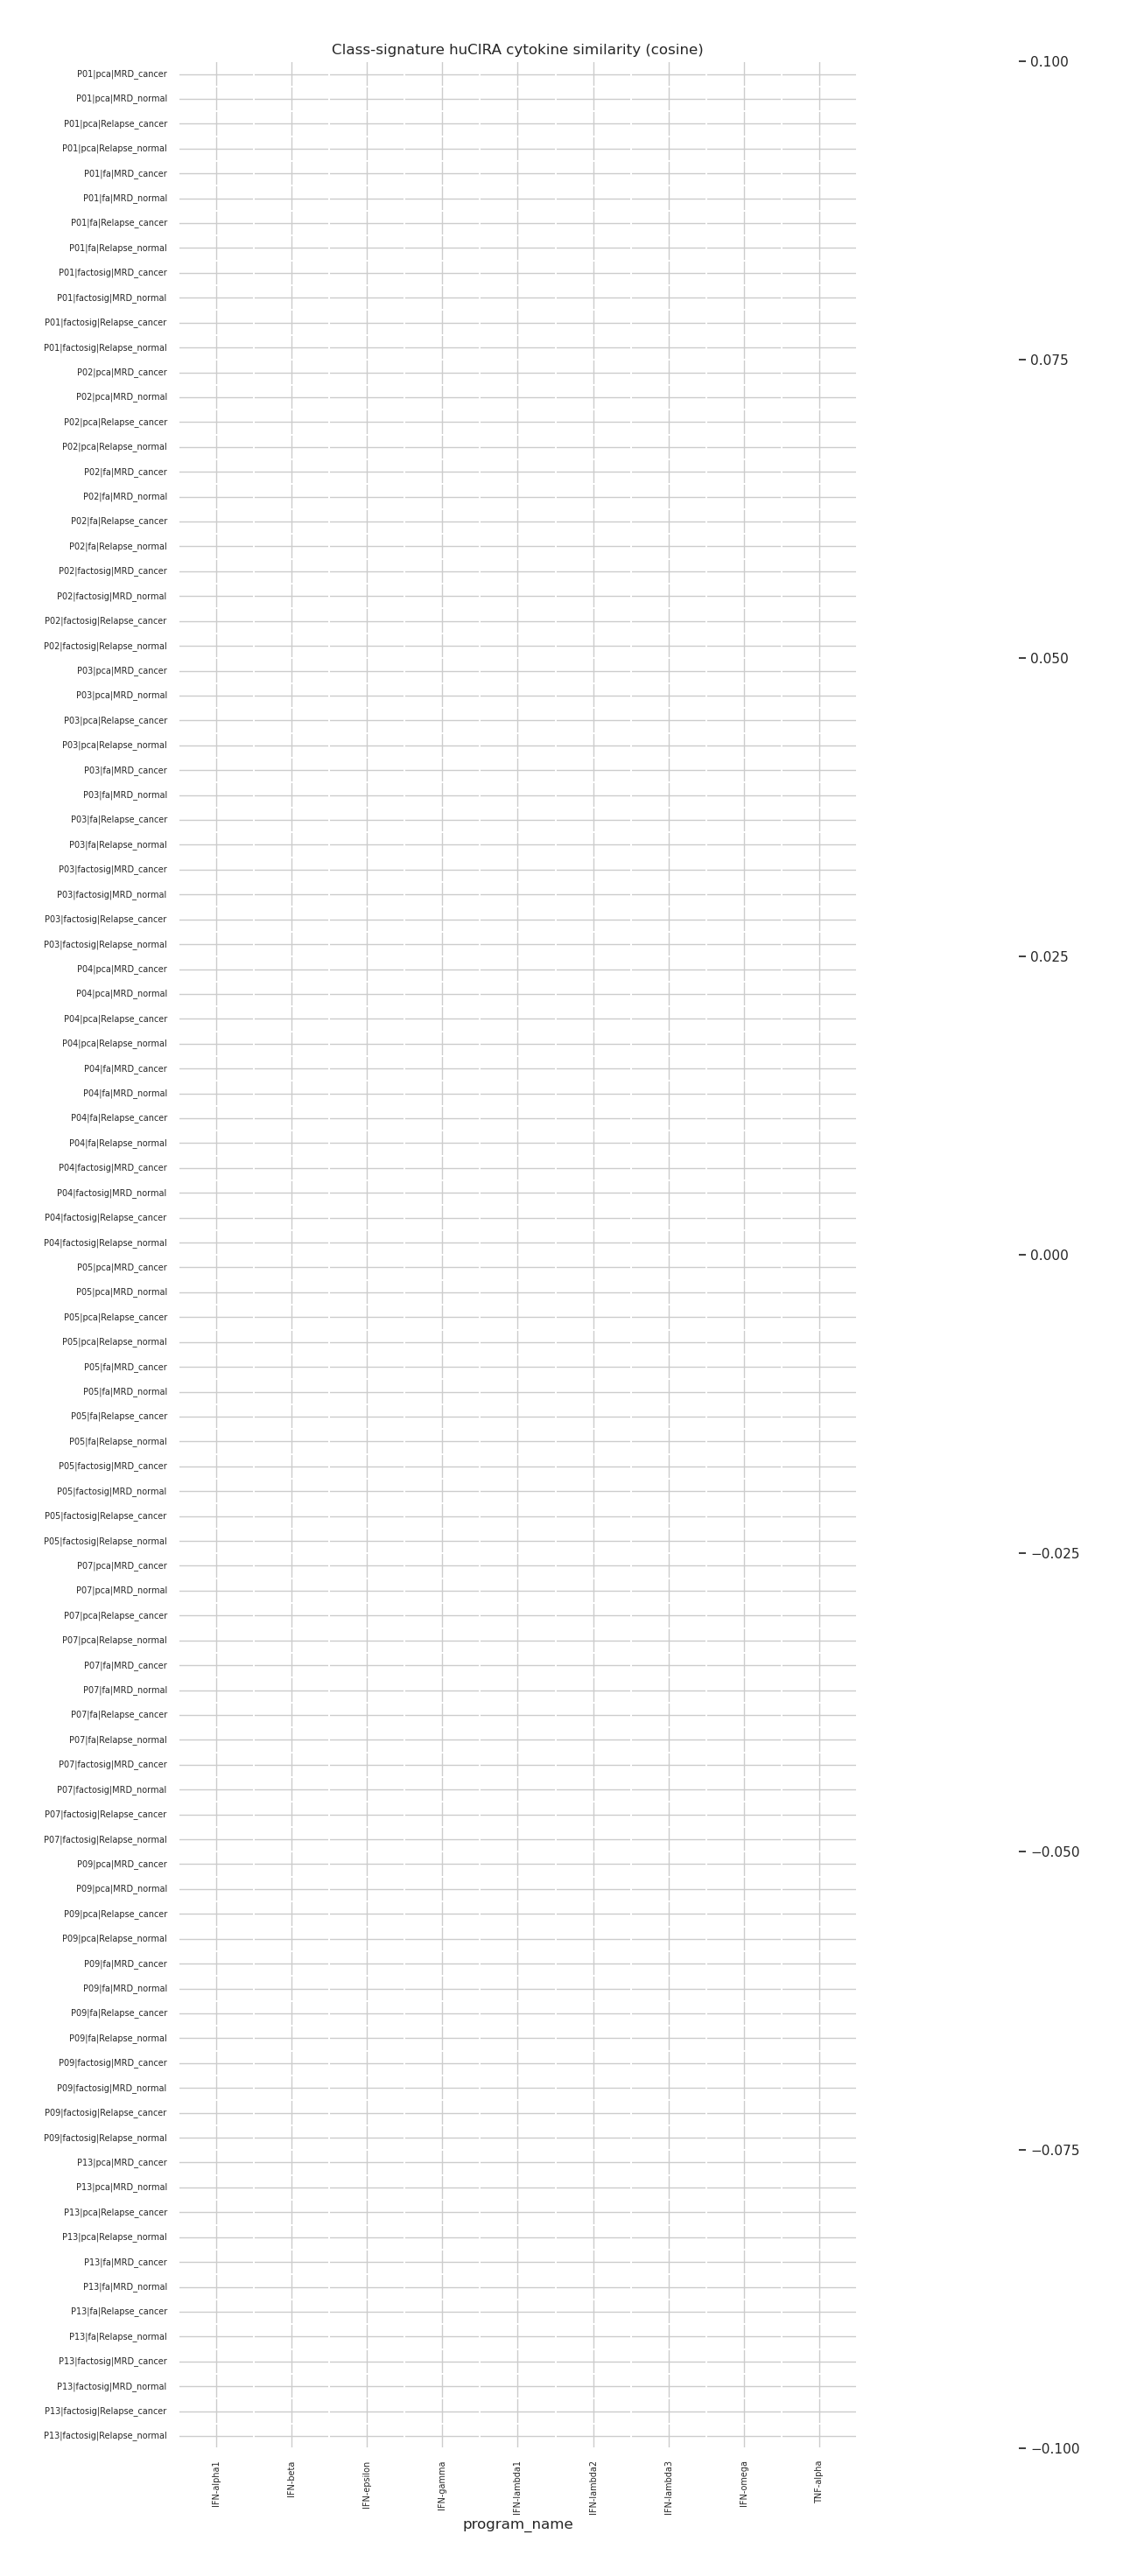

/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


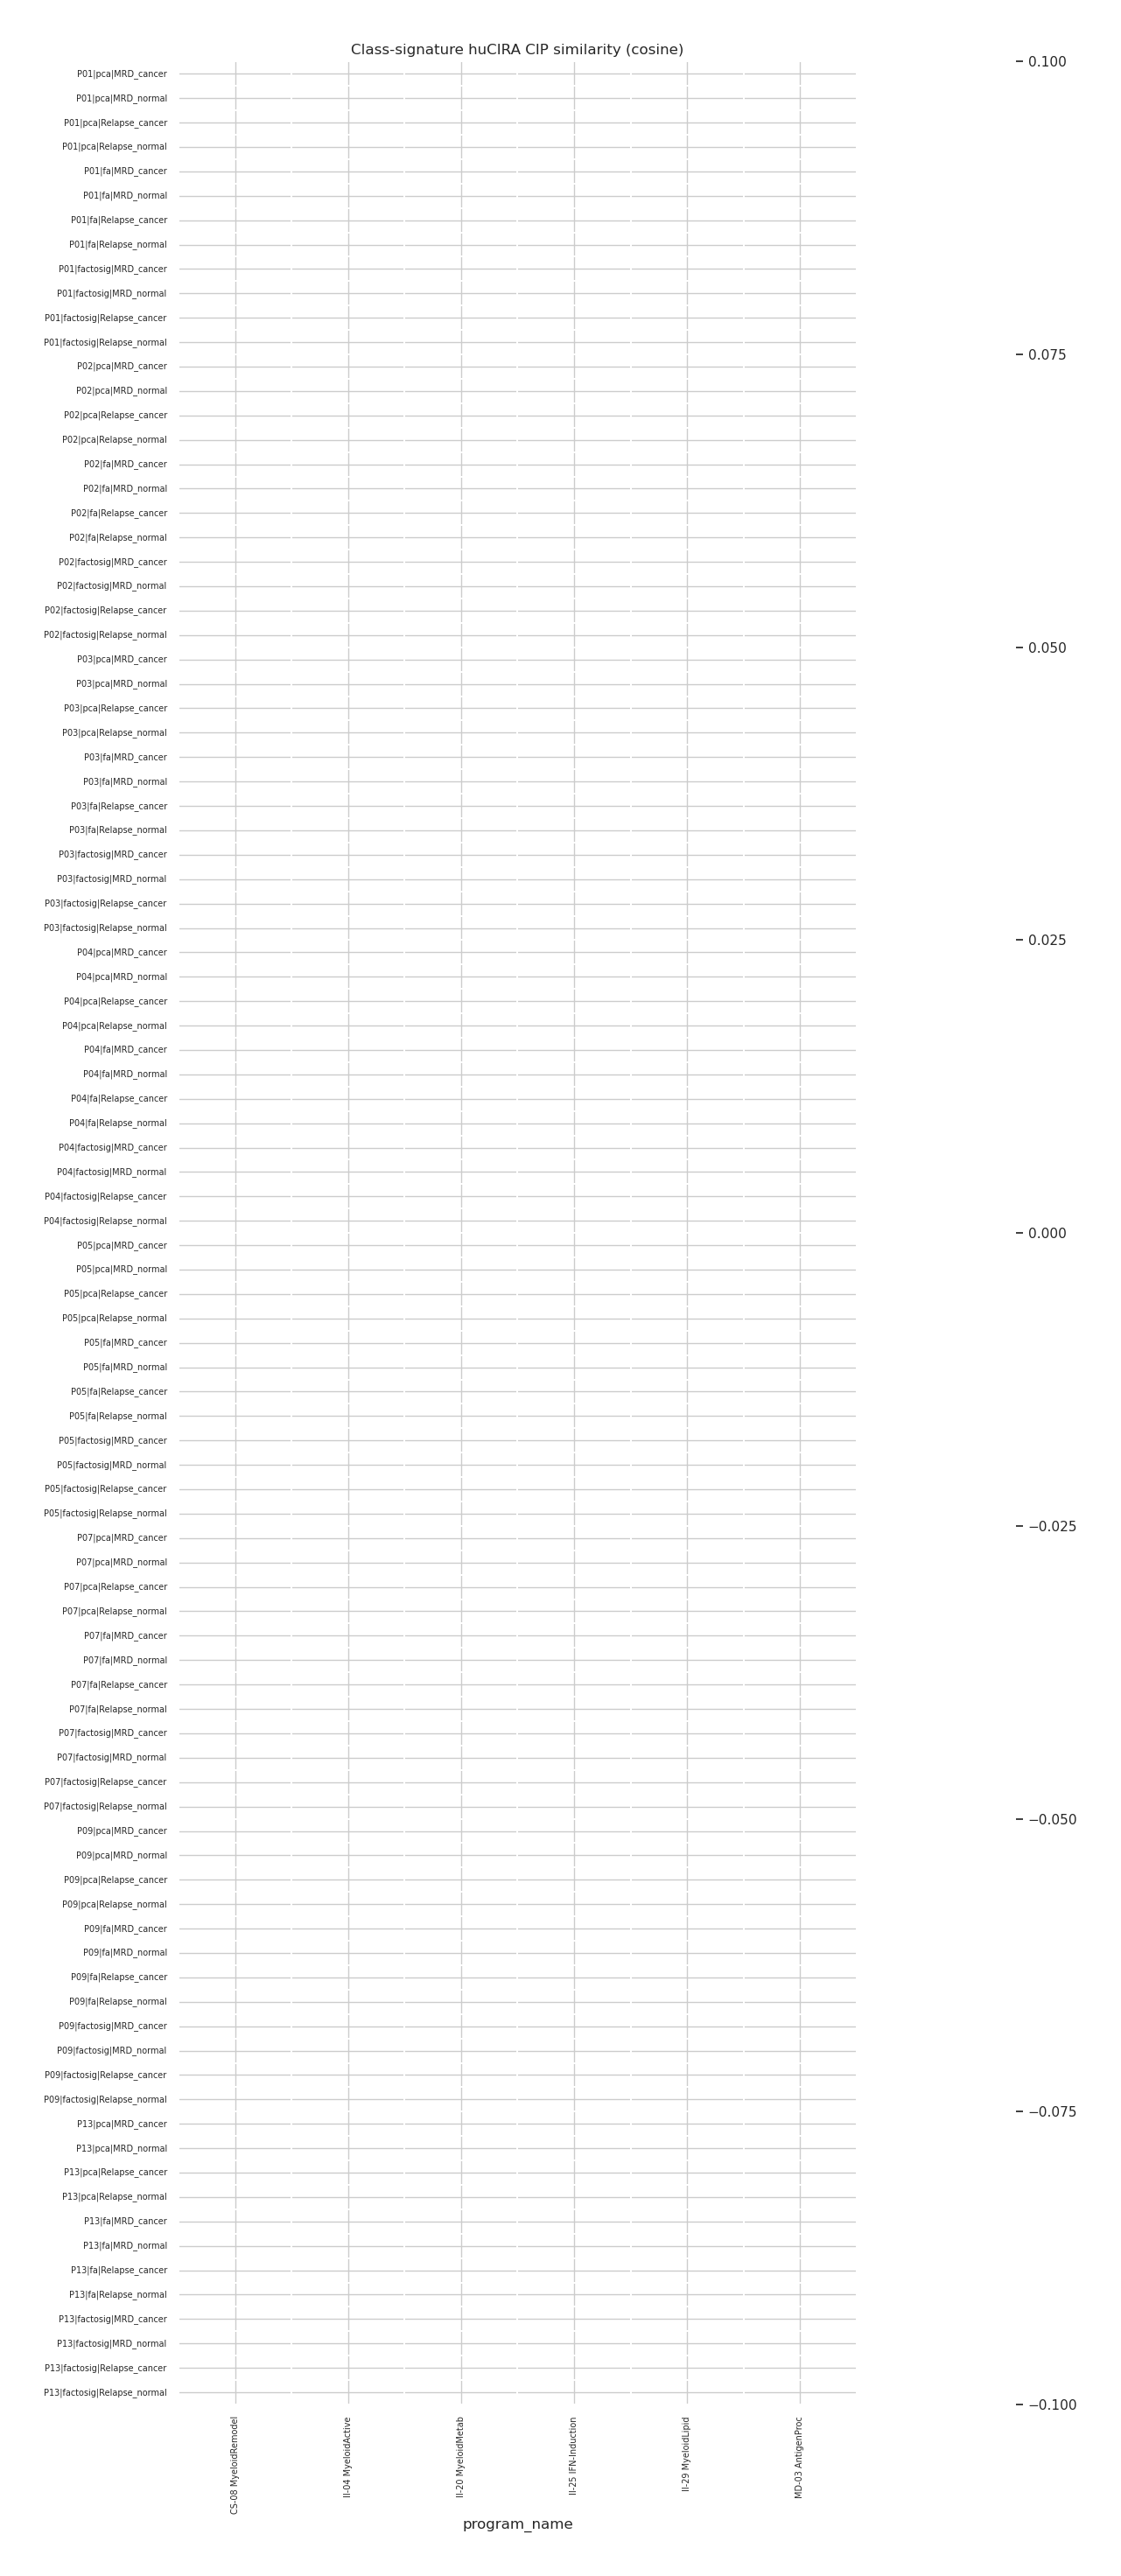

,patient,method,compartment,top_gain_programs,top_loss_programs
0,P01,fa,cancer,IFN-alpha1:nan; IFN-beta:nan; IFN-epsilon:nan,IFN-alpha1:nan; IFN-beta:nan; IFN-epsilon:nan
2,P01,factosig,cancer,IFN-alpha1:nan; IFN-beta:nan; IFN-epsilon:nan,IFN-alpha1:nan; IFN-beta:nan; IFN-epsilon:nan
4,P01,pca,cancer,IFN-alpha1:nan; IFN-beta:nan; IFN-epsilon:nan,IFN-alpha1:nan; IFN-beta:nan; IFN-epsilon:nan
6,P02,fa,cancer,IFN-alpha1:nan; IFN-beta:nan; IFN-epsilon:nan,IFN-alpha1:nan; IFN-beta:nan; IFN-epsilon:nan
8,P02,factosig,cancer,IFN-alpha1:nan; IFN-beta:nan; IFN-epsilon:nan,IFN-alpha1:nan; IFN-beta:nan; IFN-epsilon:nan
10,P02,pca,cancer,IFN-alpha1:nan; IFN-beta:nan; IFN-epsilon:nan,IFN-alpha1:nan; IFN-beta:nan; IFN-epsilon:nan
12,P03,fa,cancer,IFN-alpha1:nan; IFN-beta:nan; IFN-epsilon:nan,IFN-alpha1:nan; IFN-beta:nan; IFN-epsilon:nan
14,P03,factosig,cancer,IFN-alpha1:nan; IFN-beta:nan; IFN-epsilon:nan,IFN-alpha1:nan; IFN-beta:nan; IFN-epsilon:nan
16,P03,pca,cancer,IFN-alpha1:nan; IFN-beta:nan; IFN-epsilon:nan,IFN-alpha1:nan; IFN-beta:nan; IFN-epsilon:nan
18,P04,fa,cancer,IFN-alpha1:nan; IFN-beta:nan; IFN-epsilon:nan,IFN-alpha1:nan; IFN-beta:nan; IFN-epsilon:nan


/tmp/ipykernel_699691/729354031.py:124: RuntimeWarning: Mean of empty slice
  "mean_pairwise_hucira_profile_corr": float(np.nanmean(vals)),
/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_699691/729354031.py:124: RuntimeWarning: Mean of empty slice
  "mean_pairwise_hucira_profile_corr": float(np.nanmean(vals)),
/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_699691/729354031.py:124: RuntimeWarning: Mean of empty slice
  "mean_pairwise_hucira_profile_corr": float(np.nanmean(vals)),
/home/minhang/miniconda3/envs/sc-classification-rapids-py311/lib/python3.11/site-packages/numpy/li

,method,class_label,n_patients,mean_pairwise_hucira_profile_corr,sd_pairwise_hucira_profile_corr
0,fa,MRD_cancer,8,NaN,NaN
4,factosig,MRD_cancer,8,NaN,NaN
8,pca,MRD_cancer,8,NaN,NaN
1,fa,MRD_normal,8,NaN,NaN
5,factosig,MRD_normal,8,NaN,NaN
9,pca,MRD_normal,8,NaN,NaN
2,fa,Relapse_cancer,8,NaN,NaN
6,factosig,Relapse_cancer,8,NaN,NaN
10,pca,Relapse_cancer,8,NaN,NaN
3,fa,Relapse_normal,8,NaN,NaN


Saved huCIRA class-signature interpretation outputs to /home/minhang/mds_project/sc_classification/scripts/Relapse_MRD_DR_Classification/notebooks/outputs/relapse_mrd_multiclass_analysis_20260319/class_signatures/hucira_projection


In [6]:
# huCIRA projection of class-specific predictive signatures
from sc_classification.utils.hucira_interpretation import (
    DEFAULT_HUCIRA_PROGRAM_SUBSET,
    compute_signature_program_jaccard,
    compute_signature_program_similarity,
    export_hucira_reference_sets,
    load_hucira_reference_assets,
    select_reference_programs,
    summarize_top_program_matches,
)

HUCIRA_REFERENCE_DIR = Path("/home/minhang/mds_project/data/hucira_reference")
HUCIRA_AUTO_BUILD = False
HUCIRA_FOCUS_TERMS = DEFAULT_HUCIRA_PROGRAM_SUBSET
HUCIRA_TOP_K_MATCHES = 5
HUCIRA_TOP_HEATMAP_PROGRAMS = 40
HUCIRA_TOP_GENE_JACCARD_N = 200

if (HUCIRA_REFERENCE_DIR / "reference_table.csv").exists():
    hucira_assets = load_hucira_reference_assets(HUCIRA_REFERENCE_DIR)
elif HUCIRA_AUTO_BUILD:
    hucira_assets = export_hucira_reference_sets(HUCIRA_REFERENCE_DIR)
else:
    hucira_assets = None
    print(
        "HuCIRA reference assets not found. Run `python sc_classification/scripts/Relapse_MRD_DR_Classification/build_hucira_reference_sets.py` "
        "or set HUCIRA_AUTO_BUILD=True in an environment with `hucira` installed."
    )

if hucira_assets is not None:
    hucira_out = OUTPUT_DIR / "class_signatures" / "hucira_projection"
    hucira_out.mkdir(parents=True, exist_ok=True)

    cytokine_ref = hucira_assets["cytokine_long"]
    cip_ref = hucira_assets["cip_long"]

    cytokine_focus = select_reference_programs(cytokine_ref, include_terms=HUCIRA_FOCUS_TERMS, min_genes_per_program=10)
    cip_focus = select_reference_programs(cip_ref, include_terms=HUCIRA_FOCUS_TERMS, min_genes_per_program=10)
    if cytokine_focus.empty:
        cytokine_focus = cytokine_ref.copy()
    if cip_focus.empty:
        cip_focus = cip_ref.copy()

    cytokine_scores = compute_signature_program_similarity(sig_df, cytokine_focus, metrics=("cosine", "pearson"))
    cip_scores = compute_signature_program_similarity(sig_df, cip_focus, metrics=("cosine", "pearson"))
    cytokine_j = compute_signature_program_jaccard(sig_df, cytokine_focus, top_n=HUCIRA_TOP_GENE_JACCARD_N, direction="positive")
    cip_j = compute_signature_program_jaccard(sig_df, cip_focus, top_n=HUCIRA_TOP_GENE_JACCARD_N, direction="positive")

    cytokine_top = summarize_top_program_matches(cytokine_scores["cosine"], top_k=HUCIRA_TOP_K_MATCHES, score_name="cosine_similarity")
    cip_top = summarize_top_program_matches(cip_scores["cosine"], top_k=HUCIRA_TOP_K_MATCHES, score_name="cosine_similarity")
    display(cytokine_top)
    display(cip_top)

    def _plot_hucira_heatmap(score_df: pd.DataFrame, title: str):
        if score_df.empty:
            return
        top_programs = score_df.abs().max(axis=0).sort_values(ascending=False).head(HUCIRA_TOP_HEATMAP_PROGRAMS).index
        mat = score_df.loc[:, top_programs]
        fig, ax = plt.subplots(figsize=(max(12, 0.35 * mat.shape[1]), max(6, 0.30 * mat.shape[0])))
        sns.heatmap(mat, cmap="vlag", center=0, linewidths=0.1, linecolor="white", ax=ax)
        ax.set_title(title)
        ax.tick_params(axis="x", labelrotation=90, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)
        plt.tight_layout()
        plt.show()

    _plot_hucira_heatmap(cytokine_scores["cosine"], "Class-signature huCIRA cytokine similarity (cosine)")
    _plot_hucira_heatmap(cip_scores["cosine"], "Class-signature huCIRA CIP similarity (cosine)")

    cytokine_scores["cosine"].to_csv(hucira_out / "cytokine_similarity_cosine.csv")
    cytokine_scores["pearson"].to_csv(hucira_out / "cytokine_similarity_pearson.csv")
    cytokine_scores["overlap_n"].to_csv(hucira_out / "cytokine_overlap_counts.csv")
    cip_scores["cosine"].to_csv(hucira_out / "cip_similarity_cosine.csv")
    cip_scores["pearson"].to_csv(hucira_out / "cip_similarity_pearson.csv")
    cip_scores["overlap_n"].to_csv(hucira_out / "cip_overlap_counts.csv")
    cytokine_j.to_csv(hucira_out / f"cytokine_top{HUCIRA_TOP_GENE_JACCARD_N}_positive_gene_jaccard.csv")
    cip_j.to_csv(hucira_out / f"cip_top{HUCIRA_TOP_GENE_JACCARD_N}_positive_gene_jaccard.csv")
    cytokine_top.to_csv(hucira_out / "cytokine_top_matches.csv", index=False)
    cip_top.to_csv(hucira_out / "cip_top_matches.csv", index=False)

    # Progression delta in huCIRA space: Relapse minus MRD within cancer and normal compartments.
    progression_hucira_rows = []
    for (patient, method), sub in class_sig_meta.groupby(["patient", "method"], observed=False):
        for compartment, a, b in [
            ("cancer", f"{patient}|{method}|MRD_cancer", f"{patient}|{method}|Relapse_cancer"),
            ("normal", f"{patient}|{method}|MRD_normal", f"{patient}|{method}|Relapse_normal"),
        ]:
            if a not in cytokine_scores["cosine"].index or b not in cytokine_scores["cosine"].index:
                continue
            delta = cytokine_scores["cosine"].loc[b] - cytokine_scores["cosine"].loc[a]
            top_gain = delta.sort_values(ascending=False).head(3)
            top_loss = delta.sort_values(ascending=True).head(3)
            progression_hucira_rows.append(
                {
                    "patient": patient,
                    "method": method,
                    "compartment": compartment,
                    "top_gain_programs": "; ".join([f"{k}:{v:.3f}" for k, v in top_gain.items()]),
                    "top_loss_programs": "; ".join([f"{k}:{v:.3f}" for k, v in top_loss.items()]),
                }
            )

    progression_hucira_summary = pd.DataFrame(progression_hucira_rows).sort_values(["compartment", "patient", "method"])
    display(progression_hucira_summary)
    progression_hucira_summary.to_csv(hucira_out / "progression_hucira_delta_summary.csv", index=False)

    # Cross-patient convergence of class-specific huCIRA profiles.
    class_profile_rows = []
    for (method, class_label), sub in class_sig_meta.groupby(["method", "class_label"], observed=False):
        model_cols = [
            f"{r['patient']}|{r['method']}|{r['class_label']}"
            for _, r in sub.iterrows()
            if f"{r['patient']}|{r['method']}|{r['class_label']}" in cytokine_scores["cosine"].index
        ]
        if len(model_cols) < 2:
            continue
        sim = cytokine_scores["cosine"].loc[model_cols].T.corr(method="pearson")
        vals = sim.values[np.triu_indices_from(sim.values, k=1)]
        class_profile_rows.append(
            {
                "method": method,
                "class_label": class_label,
                "n_patients": len(model_cols),
                "mean_pairwise_hucira_profile_corr": float(np.nanmean(vals)),
                "sd_pairwise_hucira_profile_corr": float(np.nanstd(vals)),
            }
        )

    class_profile_summary = pd.DataFrame(class_profile_rows).sort_values(["class_label", "method"])
    display(class_profile_summary)
    class_profile_summary.to_csv(hucira_out / "class_profile_convergence_summary.csv", index=False)

    print("Saved huCIRA class-signature interpretation outputs to", hucira_out)

In [7]:
# Optional Hallmark GSEA for class-specific signatures
RUN_GSEA = True
GSEA_CLASS_FILTER = {"MRD_cancer", "Relapse_cancer"}
GSEA_THREADS = int(os.environ.get("GSEA_THREADS", "4"))
GSEA_PERM = int(os.environ.get("GSEA_PERM", "200"))
GSEA_MIN_SIZE = int(os.environ.get("GSEA_MIN_SIZE", "15"))
GSEA_MAX_SIZE = int(os.environ.get("GSEA_MAX_SIZE", "500"))

try:
    import gseapy as gp
except Exception:
    gp = None
    if RUN_GSEA:
        raise RuntimeError("gseapy not installed. Install with: pip install gseapy")


def _safe_name(x: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(x)).strip("_")


def _resolve_hallmark_gmt() -> Optional[Path]:
    env_path = os.environ.get("HALLMARK_GMT", "").strip()
    if env_path:
        p = Path(env_path)
        if p.exists():
            return p

    candidates = [
        Path("/home/minhang/mds_project/data/cohort_adata/gene_sets/h.all.v2024.1.Hs.symbols.gmt"),
        Path("data/msigdb/h.all.v2023.2.Hs.symbols.gmt"),
        Path("data/msigdb/h.all.v2023.1.Hs.symbols.gmt"),
        Path("data/msigdb/h.all.v7.5.1.symbols.gmt"),
    ]
    for p in candidates:
        if p.exists():
            return p

    hits = sorted(Path(".").rglob("h.all*.gmt"))
    return hits[0] if hits else None


def _read_prerank_report_auto(report_csv: Path) -> pd.DataFrame:
    for sep in [",", "\t", None]:
        try:
            if sep is None:
                df = pd.read_csv(report_csv)
            else:
                df = pd.read_csv(report_csv, sep=sep)
            if df.shape[1] > 1:
                return df
        except Exception:
            continue
    return pd.read_csv(report_csv)


def run_or_read_prerank(series: pd.Series, gene_sets: Path, out_dir: Path) -> Optional[pd.DataFrame]:
    out_dir.mkdir(parents=True, exist_ok=True)
    canonical_cache = out_dir / "prerank_res2d_cached.csv"
    if canonical_cache.exists():
        return pd.read_csv(canonical_cache)

    report_candidates = [
        out_dir / "gseapy.gene_set.prerank.report.csv",
        out_dir / "gseapy.prerank.gene_sets.report.csv",
    ]
    for report_csv in report_candidates:
        if report_csv.exists():
            df = _read_prerank_report_auto(report_csv)
            df.to_csv(canonical_cache, index=False)
            return df

    if gp is None:
        return None

    rank_df = series.reset_index()
    rank_df.columns = ["gene", "score"]
    res = gp.prerank(
        rnk=rank_df,
        gene_sets=str(gene_sets),
        threads=GSEA_THREADS,
        permutation_num=GSEA_PERM,
        outdir=str(out_dir),
        seed=0,
        min_size=GSEA_MIN_SIZE,
        max_size=GSEA_MAX_SIZE,
        no_plot=True,
        format="png",
        verbose=False,
    )
    df = res.res2d.copy()
    df.to_csv(canonical_cache, index=False)
    return df


if RUN_GSEA:
    hallmark_gmt = _resolve_hallmark_gmt()
    if hallmark_gmt is None:
        raise FileNotFoundError("No Hallmark GMT found. Set HALLMARK_GMT env var or add h.all*.gmt")

    gsea_root = OUTPUT_DIR / "hallmark_gsea_class_signatures"
    gsea_root.mkdir(parents=True, exist_ok=True)
    rows = []

    for model_uid in sig_df.columns:
        patient, method, class_label = model_uid.split("|", maxsplit=2)
        if class_label not in GSEA_CLASS_FILTER:
            continue

        rank = sig_df[model_uid].sort_values(ascending=False)
        out_dir = gsea_root / _safe_name(patient) / _safe_name(method) / _safe_name(class_label)
        df = run_or_read_prerank(rank, hallmark_gmt, out_dir)
        if df is None or df.empty:
            continue

        fdr_col = next((c for c in ["FDR q-val", "fdr", "fdr_q-val", "fdr_q_value"] if c in df.columns), None)
        nes_col = next((c for c in ["NES", "nes"] if c in df.columns), None)
        term_col = next((c for c in ["Term", "term", "NAME", "name"] if c in df.columns), None)
        fdr_num = pd.to_numeric(df[fdr_col], errors="coerce") if fdr_col is not None else pd.Series(np.nan, index=df.index)
        n_sig = int((fdr_num < 0.05).sum()) if fdr_col is not None else np.nan
        rows.append({
            "patient": patient,
            "method": method,
            "class_label": class_label,
            "model_uid": model_uid,
            "n_sig_pathways_fdr_lt_0p05": n_sig,
        })

        if term_col is not None and nes_col is not None:
            nes_df = pd.DataFrame({"term": df[term_col], "NES": pd.to_numeric(df[nes_col], errors="coerce")}).dropna(subset=["NES"])
            top_pos = nes_df.nlargest(8, "NES")
            top_neg = nes_df.nsmallest(8, "NES")
            plot_df = pd.concat([top_neg, top_pos], ignore_index=True).sort_values("NES")
            if not plot_df.empty:
                fig, ax = plt.subplots(figsize=(10, 6))
                colors = np.where(plot_df["NES"] >= 0, "#b2182b", "#2166ac")
                ax.barh(plot_df["term"], plot_df["NES"], color=colors)
                ax.axvline(0, color="black", lw=1)
                ax.set_title(f"NES: {model_uid}")
                ax.set_xlabel("Normalized Enrichment Score (NES)")
                plt.tight_layout()
                fig.savefig(out_dir / "nes_top_pos_neg_barplot.png", dpi=160)
                plt.close(fig)

    gsea_counts = pd.DataFrame(rows).sort_values(["class_label", "patient", "method"])
    display(gsea_counts)
    gsea_counts.to_csv(gsea_root / "hallmark_gsea_counts_class_signatures.csv", index=False)
    print("Saved class-signature Hallmark GSEA outputs to", gsea_root)
else:
    print("RUN_GSEA is False. Set RUN_GSEA=True to run Hallmark GSEA for cancer-class signatures.")

,patient,method,class_label,model_uid,n_sig_pathways_fdr_lt_0p05
2,P01,fa,MRD_cancer,P01|fa|MRD_cancer,32
4,P01,factosig,MRD_cancer,P01|factosig|MRD_cancer,44
0,P01,pca,MRD_cancer,P01|pca|MRD_cancer,11
8,P02,fa,MRD_cancer,P02|fa|MRD_cancer,31
10,P02,factosig,MRD_cancer,P02|factosig|MRD_cancer,32
6,P02,pca,MRD_cancer,P02|pca|MRD_cancer,15
14,P03,fa,MRD_cancer,P03|fa|MRD_cancer,44
16,P03,factosig,MRD_cancer,P03|factosig|MRD_cancer,44
12,P03,pca,MRD_cancer,P03|pca|MRD_cancer,7
20,P04,fa,MRD_cancer,P04|fa|MRD_cancer,19


Saved class-signature Hallmark GSEA outputs to /home/minhang/mds_project/sc_classification/scripts/Relapse_MRD_DR_Classification/notebooks/outputs/relapse_mrd_multiclass_analysis_20260319/hallmark_gsea_class_signatures
